# Uplift Modeling — the honest version of the decision engine

The Telco decision engine ranks customers by **churn probability x CLV**: it
targets whoever is most likely to leave. But that is not quite the right
question. What a retention team actually wants is **persuadability** — the
customers whose behaviour *changes because* of the intervention. A customer
certain to churn no matter what is wasted budget; a customer who would have
stayed anyway yields nothing.

The quantity that captures this is **uplift** (a.k.a. the treatment effect):

> uplift(x) = P(stay | treated, x) - P(stay | not treated, x)

Estimating uplift needs **experimental data**: a treated group and a control
group. The Telco dataset has no such thing — which is exactly the limitation
documented in the decision memo. This notebook demonstrates the method on a
dataset that *does* have it: **Hillstrom's email A/B test** (64,000 customers
randomly assigned to email vs no email), showing that ranking by uplift beats
ranking by response propensity — the same critique that applies to the Telco
engine.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from src.uplift import (
    load_hillstrom, fit_two_model_uplift, response_scores, qini_curve,
)

plt.rcParams.update({
    "figure.figsize": (8, 5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
})

df = load_hillstrom()
treated_rate = df.loc[df.treat == 1, "outcome"].mean()
control_rate = df.loc[df.treat == 0, "outcome"].mean()
print(f"{len(df):,} customers | treated visit rate {treated_rate:.1%} vs "
      f"control {control_rate:.1%} -> average uplift {100*(treated_rate-control_rate):.1f}pp")

64,000 customers | treated visit rate 16.7% vs control 10.6% -> average uplift 6.1pp


## The experiment

Because treatment was assigned at random, the difference in visit rate between
the emailed and control groups is a clean estimate of the **average** treatment
effect (~6 percentage points). Uplift modeling goes further: it estimates the
effect *per customer*, so we can target the customers with the largest effect.

## Two-model (T-learner) uplift

Fit one outcome model on the treated group and one on the control group; the
per-customer uplift is the difference in their predicted probabilities. We
compare three ways of ranking customers:

- **Uplift** — rank by estimated treatment effect (persuadability)
- **Response propensity** — rank by who is most likely to visit (ignoring
  treatment) — this is the Telco-style "target the likely responders" approach
- **Random** — a baseline

In [2]:
uplift = fit_two_model_uplift(df)
propensity = response_scores(df)
rng = np.random.default_rng(0)
rand = rng.random(len(df))

f_up, q_up, c_up = qini_curve(uplift, df.treat, df.outcome)
f_pr, q_pr, c_pr = qini_curve(propensity, df.treat, df.outcome)
f_rn, q_rn, c_rn = qini_curve(rand, df.treat, df.outcome)

print(f"Qini coefficient  uplift={c_up:,.0f}  propensity={c_pr:,.0f}  random={c_rn:,.0f}")

Qini coefficient  uplift=1,083  propensity=148  random=62


## Qini curve

The **Qini curve** plots cumulative *incremental* responders (treated responders
minus control responders, scaled) as we target more of the population, ranked by
each score. A curve that rises fast and high means the ranking concentrates the
customers who are genuinely swayed by the offer. The area over the random
diagonal is the **Qini coefficient**.

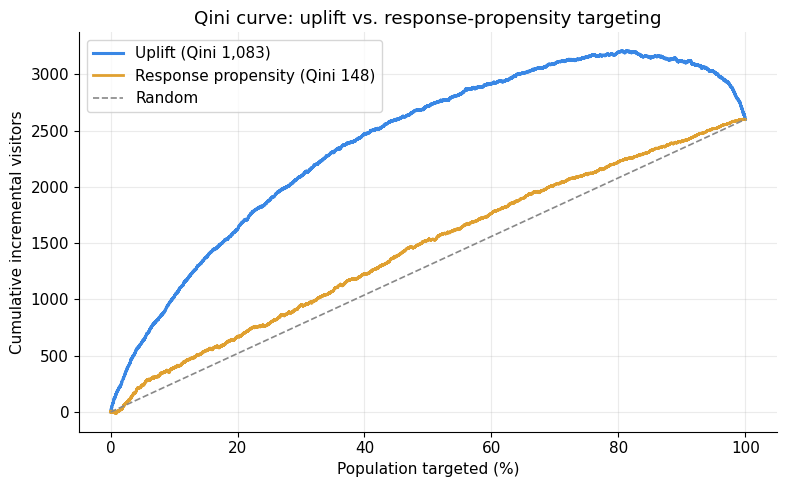

In [3]:
fig, ax = plt.subplots()
ax.plot(f_up*100, q_up, color="#3987e5", lw=2.2, label=f"Uplift (Qini {c_up:,.0f})")
ax.plot(f_pr*100, q_pr, color="#e0a030", lw=2, label=f"Response propensity (Qini {c_pr:,.0f})")
ax.plot([0,100], [0, q_up[-1]], color="#888", lw=1.2, ls="--", label="Random")
ax.set_xlabel("Population targeted (%)")
ax.set_ylabel("Cumulative incremental visitors")
ax.set_title("Qini curve: uplift vs. response-propensity targeting")
ax.legend()
plt.tight_layout(); plt.show()

## What this proves

Ranking by **uplift** captures far more incremental responders than ranking by
**response propensity** — the Qini coefficient is several times larger. Targeting
the customers *most likely to respond* wastes budget on people who would have
responded anyway; targeting the customers *most changed by the offer* is what
actually creates value.

**Back to the Telco engine.** This is precisely the critique of ranking by
`churn probability x CLV`: it targets likely-churners, not persuadable ones. The
engine's architecture already supports the fix — swap the churn-probability
score for an uplift score and rank by `uplift x CLV`. The only missing
ingredient is a randomized retention campaign to produce the treatment/control
data. Until that exists, the `save_rate` assumption is the transparent
stand-in, and the sensitivity/Monte-Carlo analyses bound how much it matters.